<a href="https://colab.research.google.com/github/debolton/MusicAnnotationProject/blob/main/MusicAnnotationProject_V3_1_00_Incremental_Align_and_AutoMasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Music Annotation Project V3.0 Incremental: Align Pages and Create Automatic Masks

**Runtime:** CPU. Select **Runtime > Run all**.

This version processes only pages whose clean or annotated source file is new or changed. It records source hashes in `pipeline_state/notebook0_alignment_state.json`.

A page is rebuilt when:
- either source file is new or has changed;
- an expected aligned, auto-mask or review output is missing;
- registration or auto-mask settings in `project_config.json` change;
- `FORCE_REBUILD_ALL=True` is set below.

Unchanged pages are skipped. Existing corrected masks are never modified.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, cv2, json, shutil, hashlib, re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timezone

CONFIG_PATH=Path('/content/drive/MyDrive/MusicAnnotationProject/project_config.json')
if not CONFIG_PATH.exists(): raise RuntimeError(f'Missing configuration file: {CONFIG_PATH}')
CONFIG=json.loads(CONFIG_PATH.read_text())
ROOT=Path(CONFIG['project_root'])
EXTENSIONS={'.jpg','.jpeg','.png','.tif','.tiff'}

def image_files(folder):
    folder=Path(folder)
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in EXTENSIONS]) if folder.exists() else []

def page_names(folder): return sorted({p.stem for p in image_files(folder)})

def find_image(folder,page_name):
    hits=[p for p in image_files(folder) if p.stem.lower()==page_name.lower()]
    if len(hits)>1: raise RuntimeError(f'Multiple files found for {page_name} in {folder}: {hits}')
    return hits[0] if hits else None

def md5_file(path):
    h=hashlib.md5()
    with open(path,'rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''): h.update(block)
    return h.hexdigest()

def object_hash(value): return hashlib.md5(json.dumps(value,sort_keys=True).encode()).hexdigest()

def read_json(path,default):
    try: return json.loads(Path(path).read_text()) if Path(path).exists() else default
    except Exception: return default

def write_json_atomic(path,value):
    path=Path(path); temp=path.with_suffix(path.suffix+'.tmp'); temp.write_text(json.dumps(value,indent=2)); temp.replace(path)

def remove_if_exists(path):
    path=Path(path)
    if path.exists(): path.unlink()

def create_overlay(base,mask,opacity=.60,colour=(0,0,255)):
    base_colour=cv2.cvtColor(base,cv2.COLOR_GRAY2BGR) if base.ndim==2 else base.copy()
    layer=base_colour.copy(); layer[mask>0]=colour
    return cv2.addWeighted(base_colour,1-opacity,layer,opacity,0)

def show_images(paths,columns=2,limit=24):
    paths=list(paths)[:limit]
    if not paths: print('No preview images found.'); return
    rows=int(np.ceil(len(paths)/columns)); plt.figure(figsize=(columns*7,rows*6))
    for i,path in enumerate(paths):
        image=cv2.imread(str(path))
        if image is None: continue
        plt.subplot(rows,columns,i+1); plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB)); plt.title(Path(path).name); plt.axis('off')
    plt.tight_layout(); plt.show()

Mounted at /content/drive


## Paths and incremental controls

In [ ]:
CLEAN_DIR=ROOT/'source'/'clean'; ANNOTATED_DIR=ROOT/'source'/'annotated'; ALIGNED_DIR=ROOT/'aligned'; AUTO_MASK_DIR=ROOT/'masks'/'auto'; CORRECTED_MASK_DIR=ROOT/'masks'/'corrected'; GOLD_STANDARD_DIR=ROOT/'gold_standard_testing'; REG_REVIEW_DIR=ROOT/'review'/'registration'; AUTO_REVIEW_DIR=ROOT/'review'/'auto_masks'; STATE_DIR=ROOT/'pipeline_state'; STATE_PATH=STATE_DIR/'notebook0_alignment_state.json'
FORCE_REBUILD_ALL=False
REMOVE_OUTPUTS_FOR_DELETED_SOURCES=False
for folder in [CLEAN_DIR,ANNOTATED_DIR,ALIGNED_DIR,AUTO_MASK_DIR,CORRECTED_MASK_DIR,GOLD_STANDARD_DIR,REG_REVIEW_DIR,AUTO_REVIEW_DIR,STATE_DIR]: folder.mkdir(parents=True,exist_ok=True)
clean=set(page_names(CLEAN_DIR)); annotated=set(page_names(ANNOTATED_DIR)); matched=sorted(clean&annotated)
print('Matched source pairs:',len(matched)); print('Clean without annotated:',sorted(clean-annotated)); print('Annotated without clean:',sorted(annotated-clean))
if not matched: raise RuntimeError('No matching clean/annotated source pairs found.')

Matched source pairs: 83
Clean without annotated: []
Annotated without clean: []


## Registration and auto-mask functions

In [ ]:
REG=CONFIG['registration']; AM=CONFIG['auto_mask']
SETTINGS_HASH=object_hash({'registration':REG,'auto_mask':AM})
def align_pair(clean_path,annotated_path):
    clean=cv2.imread(str(clean_path),0); annotated=cv2.imread(str(annotated_path),0)
    if clean is None or annotated is None: raise ValueError('Unreadable image pair')
    cs=min(1.0,REG['max_feature_dimension']/max(clean.shape)); ans=min(1.0,REG['max_feature_dimension']/max(annotated.shape))
    clean_small=cv2.resize(clean,None,fx=cs,fy=cs,interpolation=cv2.INTER_AREA); ann_small=cv2.resize(annotated,None,fx=ans,fy=ans,interpolation=cv2.INTER_AREA)
    clahe=cv2.createCLAHE(2.0,(8,8)); sift=cv2.SIFT_create(nfeatures=REG['sift_features'],contrastThreshold=.015,edgeThreshold=15)
    ak,ad=sift.detectAndCompute(clahe.apply(ann_small),None); ck,cd=sift.detectAndCompute(clahe.apply(clean_small),None)
    if ad is None or cd is None: raise ValueError('SIFT descriptors missing')
    matcher=cv2.FlannBasedMatcher(dict(algorithm=1,trees=5),dict(checks=120)); good=[]
    for pair in matcher.knnMatch(ad,cd,k=2):
        if len(pair)==2 and pair[0].distance<REG['ratio_test']*pair[1].distance: good.append(pair[0])
    if len(good)<20: raise ValueError(f'Only {len(good)} good matches')
    src=np.float32([ak[m.queryIdx].pt for m in good])/ans; dst=np.float32([ck[m.trainIdx].pt for m in good])/cs
    H,inliers=cv2.findHomography(src,dst,cv2.RANSAC,REG['ransac_threshold'],maxIters=15000,confidence=.999)
    if H is None: raise ValueError('Homography failed')
    aligned=cv2.warpPerspective(annotated,H,(clean.shape[1],clean.shape[0]),flags=cv2.INTER_CUBIC,borderValue=255)
    diagnostics={'matches':len(good),'inliers':int(inliers.sum()),'inlier_percentage':round(100*int(inliers.sum())/len(good),2),'clean_shape':list(clean.shape),'annotated_shape':list(annotated.shape)}
    return clean,aligned,H,diagnostics

def registration_preview(clean,aligned):
    preview=np.zeros((*clean.shape,3),np.uint8); preview[:,:,1]=clean; preview[:,:,2]=aligned; return preview

def generate_auto_mask(clean,aligned):
    cb=cv2.GaussianBlur(clean,(0,0),AM['background_blur_sigma']); ab=cv2.GaussianBlur(aligned,(0,0),AM['background_blur_sigma'])
    strength=cv2.subtract(cv2.subtract(ab,aligned),cv2.subtract(cb,clean)); strength=cv2.GaussianBlur(strength,(3,3),0)
    _,mask=cv2.threshold(strength,AM['threshold'],255,cv2.THRESH_BINARY)
    mask=cv2.morphologyEx(mask,cv2.MORPH_OPEN,np.ones((2,2),np.uint8)); mask=cv2.morphologyEx(mask,cv2.MORPH_CLOSE,cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3)))
    n,labels,stats,_=cv2.connectedComponentsWithStats(mask,8); cleaned=np.zeros_like(mask)
    for i in range(1,n):
        if stats[i,cv2.CC_STAT_AREA]>=AM['minimum_component_area']: cleaned[labels==i]=255
    return strength,cleaned

## Determine changed pages and process only those pages

Pages to process: ['HNT01', 'HNT03']
Unchanged pages skipped: 81
Processed HNT01
Processed HNT03
Processed: ['HNT01', 'HNT03']
Skipped: 81
Failures: []
State: /content/drive/MyDrive/MusicAnnotationProject/pipeline_state/notebook0_alignment_state.json


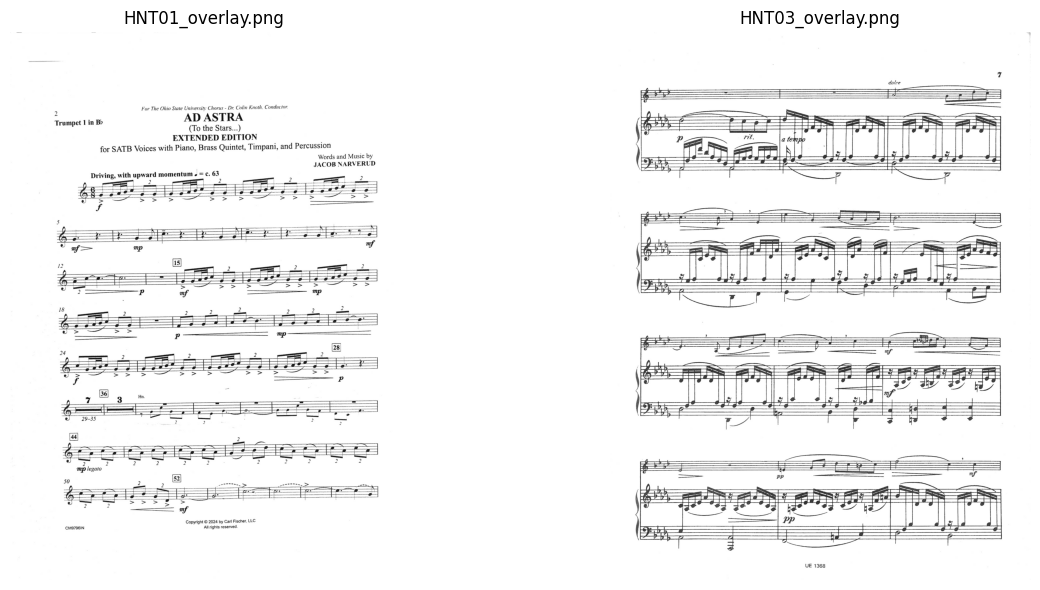

Save newly corrected masks to: /content/drive/MyDrive/MusicAnnotationProject/masks/corrected


In [ ]:
state=read_json(STATE_PATH,{'version':1,'pages':{}}); old_pages=state.get('pages',{}); current={}; to_process=[]; skipped=[]
for page in matched:
    clean_path=find_image(CLEAN_DIR,page); annotated_path=find_image(ANNOTATED_DIR,page)
    fingerprint={'clean_path':str(clean_path),'annotated_path':str(annotated_path),'clean_md5':md5_file(clean_path),'annotated_md5':md5_file(annotated_path),'settings_hash':SETTINGS_HASH}
    expected=[ALIGNED_DIR/f'{page}.png',AUTO_MASK_DIR/f'{page}.png',REG_REVIEW_DIR/f'{page}_registration.png',REG_REVIEW_DIR/f'{page}_homography.npy',REG_REVIEW_DIR/f'{page}_registration.json',AUTO_REVIEW_DIR/f'{page}_strength.png',AUTO_REVIEW_DIR/f'{page}_overlay.png']
    unchanged=(not FORCE_REBUILD_ALL and old_pages.get(page,{}).get('fingerprint')==fingerprint and all(p.exists() for p in expected))
    current[page]={'fingerprint':fingerprint,'status':'current' if unchanged else 'pending'}
    (skipped if unchanged else to_process).append(page)
print('Pages to process:',to_process); print('Unchanged pages skipped:',len(skipped))

failures=[]; processed=[]
for page in to_process:
    try:
        clean,aligned,H,diagnostics=align_pair(find_image(CLEAN_DIR,page),find_image(ANNOTATED_DIR,page))
        strength,mask=generate_auto_mask(clean,aligned)
        outputs={
          'aligned':ALIGNED_DIR/f'{page}.png','registration_preview':REG_REVIEW_DIR/f'{page}_registration.png','homography':REG_REVIEW_DIR/f'{page}_homography.npy','diagnostics':REG_REVIEW_DIR/f'{page}_registration.json','auto_mask':AUTO_MASK_DIR/f'{page}.png','strength':AUTO_REVIEW_DIR/f'{page}_strength.png','auto_overlay':AUTO_REVIEW_DIR/f'{page}_overlay.png'}
        cv2.imwrite(str(outputs['aligned']),aligned); cv2.imwrite(str(outputs['registration_preview']),registration_preview(clean,aligned)); np.save(outputs['homography'],H); outputs['diagnostics'].write_text(json.dumps(diagnostics,indent=2)); cv2.imwrite(str(outputs['auto_mask']),mask); cv2.imwrite(str(outputs['strength']),strength); cv2.imwrite(str(outputs['auto_overlay']),create_overlay(aligned,mask,.55))
        current[page].update({'status':'current','processed_utc':datetime.now(timezone.utc).isoformat(),'diagnostics':diagnostics,'outputs':{k:str(v) for k,v in outputs.items()}}); processed.append(page); print('Processed',page)
    except Exception as error:
        failures.append((page,str(error))); current[page].update({'status':'failed','error':str(error)}); print('FAILED',page,error)

if REMOVE_OUTPUTS_FOR_DELETED_SOURCES:
    for page in sorted(set(old_pages)-set(matched)):
        for path in [ALIGNED_DIR/f'{page}.png',AUTO_MASK_DIR/f'{page}.png',REG_REVIEW_DIR/f'{page}_registration.png',REG_REVIEW_DIR/f'{page}_homography.npy',REG_REVIEW_DIR/f'{page}_registration.json',AUTO_REVIEW_DIR/f'{page}_strength.png',AUTO_REVIEW_DIR/f'{page}_overlay.png']: remove_if_exists(path)
state={'version':2,'updated_utc':datetime.now(timezone.utc).isoformat(),'settings_hash':SETTINGS_HASH,'pages':current}; write_json_atomic(STATE_PATH,state)
print('Processed:',processed); print('Skipped:',len(skipped)); print('Failures:',failures); print('State:',STATE_PATH)
show_images([AUTO_REVIEW_DIR/f'{page}_overlay.png' for page in processed],columns=2)
print('Save newly corrected masks to:',CORRECTED_MASK_DIR)